In [1]:
import numpy as np
import classy
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'notebook','ieee'])
import pandas as pd
import requests
import io


In [10]:
# 1. Define Fixed Parameters (Planck 2018)
omega_b = 0.02237
omega_cdm = 0.1200
h = 0.6736
tau_reio = 0.0544
log_V0_fixed = -12.0  # Fixing V0 since we are varying N_star
alpha_fixed = 1.0     # Fixing alpha since we are varying N_star

# 2. Values of N_star to test (linear spacing from 50 to 70)
N_star_values = np.linspace(40, 80, 200)
l_max = 3500

results = {}


In [11]:
# 2. Values of N_star to test (linear spacing from 50 to 70)
for N_val in N_star_values:
    print(f"Computing for N_star = {N_val:.2f}...")
    
    cosmo = classy.Class()
    params = {
        'output': 'tCl,pCl,lCl',
        'modes': 's,t',
        'lensing': 'yes',
        'omega_b': omega_b,
        'omega_cdm': omega_cdm,
        'h': h,
        'tau_reio': tau_reio,
        'N_star': N_val,               # Varying N_star
        'l_max_scalars': l_max,
        'Pk_ini_type': 'inflation_V_end',
        'full_potential': 'alphastaro',
        'inflation_behavior': 'numerical',
        'Vparam0': 10.**log_V0_fixed,  # Fixed V0
        'Vparam1': alpha_fixed,        # Fixed alpha
        'k_pivot': 0.05
    }
    
    try:
        cosmo.set(params)
        cosmo.compute()
        
        # Get lensed Cls
        cls = cosmo.lensed_cl(l_max)
        ell = cls['ell']
        # Factor l(l+1)/2pi to get D_l
        factor = ell * (ell + 1) / (2 * np.pi)
        
        results[N_val] = {
            'ell': ell,
            'tt': cls['tt'] * factor * 1e12 # Convert to muK^2
        }
        
    except Exception as e:
        print(f"Failed at N_star {N_val}: {e}")
    
    cosmo.struct_cleanup()
    cosmo.empty()

Computing for N_star = 40.00...
Computing for N_star = 40.20...
Computing for N_star = 40.40...
Computing for N_star = 40.60...
Computing for N_star = 40.80...
Computing for N_star = 41.01...
Computing for N_star = 41.21...
Computing for N_star = 41.41...
Computing for N_star = 41.61...
Computing for N_star = 41.81...
Computing for N_star = 42.01...
Computing for N_star = 42.21...
Computing for N_star = 42.41...
Computing for N_star = 42.61...
Computing for N_star = 42.81...
Computing for N_star = 43.02...
Computing for N_star = 43.22...
Computing for N_star = 43.42...
Computing for N_star = 43.62...
Computing for N_star = 43.82...
Computing for N_star = 44.02...
Computing for N_star = 44.22...
Computing for N_star = 44.42...
Computing for N_star = 44.62...
Computing for N_star = 44.82...
Computing for N_star = 45.03...
Computing for N_star = 45.23...
Computing for N_star = 45.43...
Computing for N_star = 45.63...
Computing for N_star = 45.83...
Computing for N_star = 46.03...
Computin

In [12]:
import urllib.request
# --- 2. DOWNLOAD BOTH PLANCK DATA SETS ---
print("Downloading Planck 2018 data...")
url_binned = "https://irsa.ipac.caltech.edu/data/Planck/release_3/ancillary-data/cosmoparams/COM_PowerSpect_CMB-TT-binned_R3.01.txt"
url_full = "https://irsa.ipac.caltech.edu/data/Planck/release_3/ancillary-data/cosmoparams/COM_PowerSpect_CMB-TT-full_R3.01.txt"

binned_data = np.loadtxt(urllib.request.urlopen(url_binned))
full_data = np.loadtxt(urllib.request.urlopen(url_full))

# Extract Low-ell (unbinned, l < 30)
low_l_mask = full_data[:, 0] < 30
p_l_low = full_data[low_l_mask, 0]
p_dl_low = full_data[low_l_mask, 1]
p_err_low = [full_data[low_l_mask, 2], full_data[low_l_mask, 3]]

# Extract High-ell (binned, usually starts at l=30)
p_l_high = binned_data[:, 0]
p_dl_high = binned_data[:, 1]
p_err_high = [binned_data[:, 2], binned_data[:, 3]]

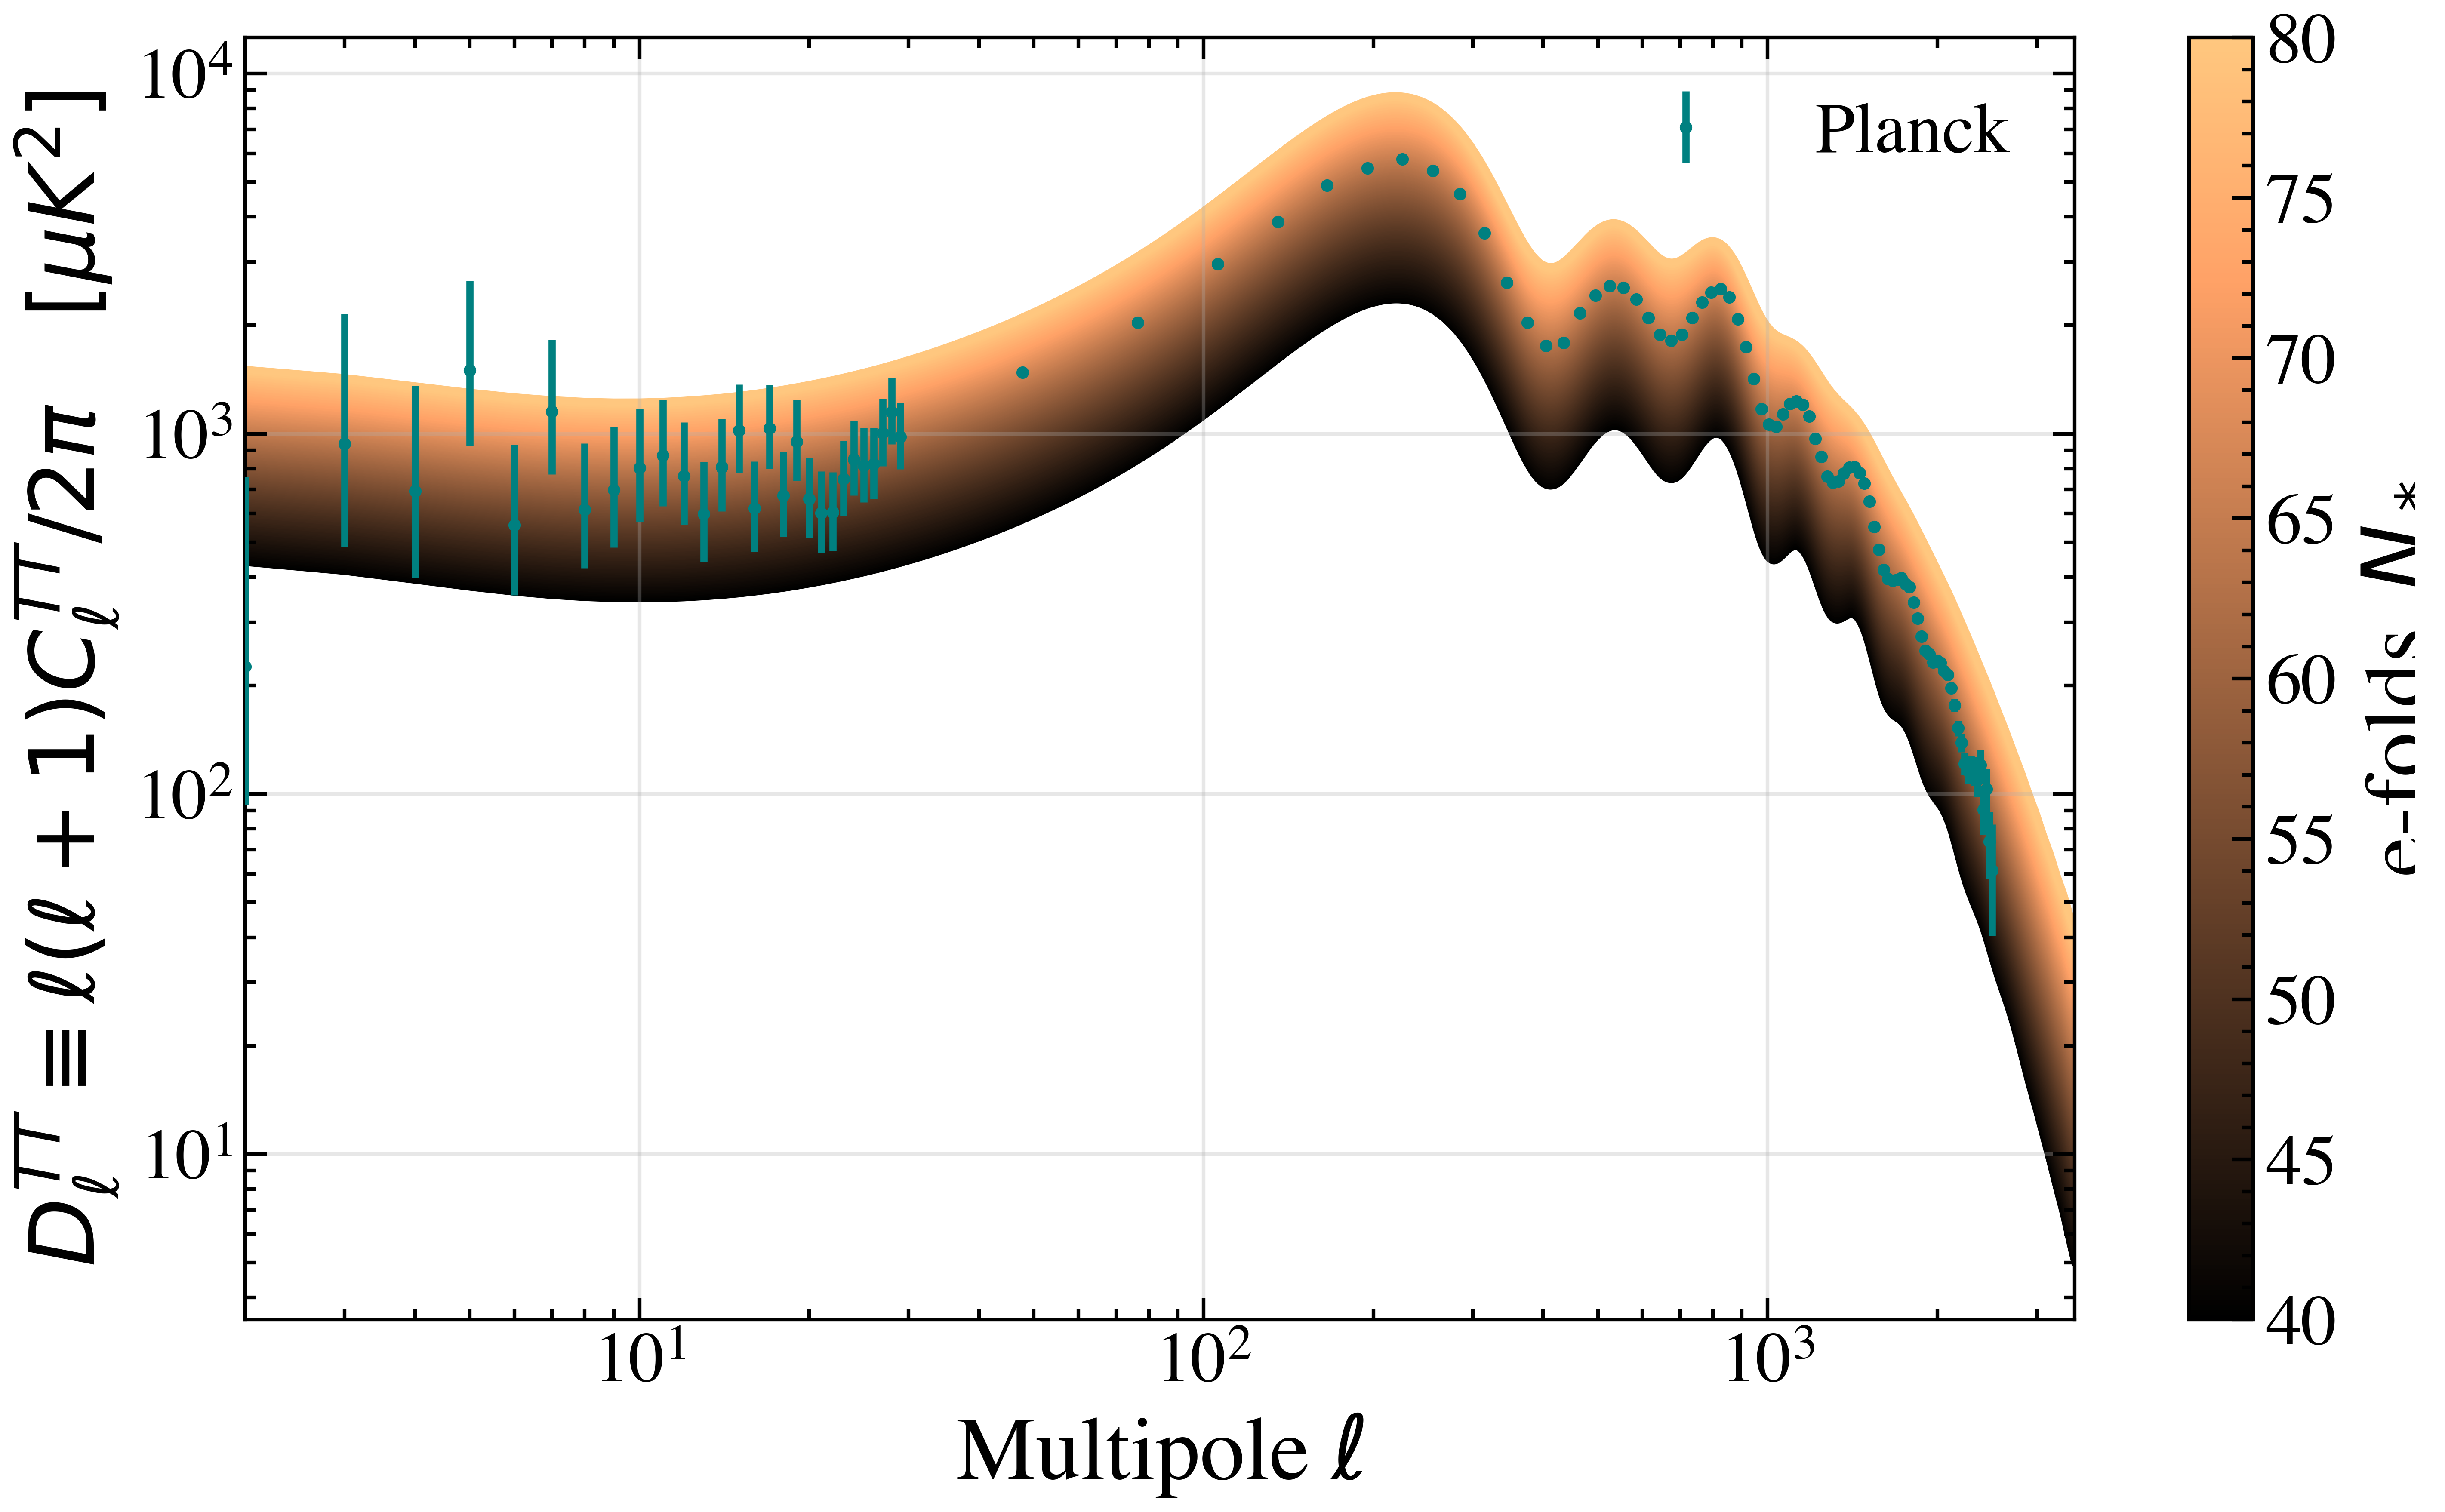

In [23]:
# 3. Plotting the results
plt.figure(figsize=(10, 6))

# --- COLORBAR SETUP ---
cmap = plt.cm.copper 
# Normalize the colormap to the range of N_star values
norm = plt.Normalize(vmin=min(N_star_values), vmax=max(N_star_values))
# ----------------------

# --- ADDED PLANCK DATA PLOTTING ---
# Low-ell Planck Data (l < 30) - zorder brings it to the front
plt.errorbar(p_l_low, p_dl_low, yerr=p_err_low, fmt='.', color='teal', 
             markersize=5, label='Planck', alpha=1.0, capsize=0, zorder=3)

# High-ell Planck Data (l >= 30) - zorder brings it to the front
plt.errorbar(p_l_high, p_dl_high, yerr=p_err_high, fmt='.', color='teal', 
             markersize=5, alpha=1.0, capsize=0, label='_nolegend_', zorder=3)
# ----------------------------------

for N_val, data in results.items():
    # Match line color to the N_star value in the loop
    plt.loglog(data['ell'][2:], data['tt'][2:], ls='-', color=cmap(norm(N_val)), zorder=1)

plt.xlabel(r'Multipole $\ell$', fontsize=25)
plt.ylabel(r'$D_\ell^{TT} \equiv \ell (\ell+1) C_\ell^{TT}/2\pi \quad [\mu K^2]$', fontsize=25)
# 1. Increase axis tick label sizes
plt.xticks(fontsize=20) 
plt.yticks(fontsize=20)
plt.grid(True, alpha=0.3)
plt.xlim(2, l_max)

# Legend now only shows the Planck data point
plt.legend(frameon=False, fontsize=20) 


# --- DRAW THE COLORBAR ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = plt.colorbar(sm, ax=plt.gca())

# 2. Increase colorbar label and tick sizes
cb.set_label(label=r'e-folds $\, N_*$', size=25) # Change text based on the script



cb.ax.tick_params(labelsize=20) 


plt.tight_layout()
# Save with tight bounding box to include the legend (updated filename)
plt.savefig('TT_vary_Nstar.pdf', bbox_inches='tight')

plt.show()